=== Model performance ===
Train | RMSE = 15.40 | MAE = 12.49 | R^2 = 0.8973
Test  | RMSE = 15.72 | MAE = 11.91 | R^2 = 0.8660

=== Coefficient table ===
                coef   std err         t     p-value                  95% CI
Intercept    19.6224    4.7105      4.17   5.124e-05   [  10.318,   28.927]
Size          0.7969    0.0219     36.37           0   [   0.754,    0.840]
Bedrooms      4.9639    0.8013      6.19   4.968e-09   [   3.381,    6.547]
Age          -0.6183    0.1091     -5.67   6.742e-08   [  -0.834,   -0.403]

R^2 = 0.8973 | Adjusted R^2 = 0.8954
F-statistic = 454.46 (p-value = 1.11e-16)

Normal equation: [19.6224  0.7969  4.9639 -0.6183]
Gradient descent: [19.6224  0.7969  4.9639 -0.6183]
Max difference vs np.linalg.lstsq: 6.927791673660977e-13


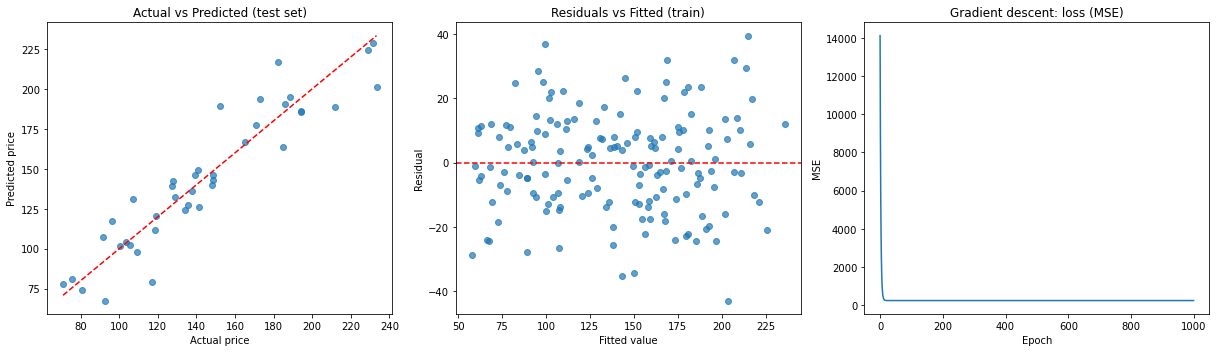

Execution complete.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats   # only used for the t and F distributions (p-values)


rng = np.random.default_rng(42)
n = 200

size     = rng.uniform(50, 250, n)        # area in square meters
bedrooms = rng.integers(1, 6, n)          # number of bedrooms
age      = rng.uniform(0, 40, n)          # age of house in years

# True relationship + random noise
price = 20 + 0.8*size + 5*bedrooms - 0.6*age + rng.normal(0, 15, n)

X_raw = np.column_stack([size, bedrooms, age])
feature_names = ["Intercept", "Size", "Bedrooms", "Age"]


idx = rng.permutation(n)
split = int(0.8 * n)
train, test = idx[:split], idx[split:]

X_train = np.column_stack([np.ones(len(train)), X_raw[train]])  # add intercept column
X_test  = np.column_stack([np.ones(len(test)),  X_raw[test]])
y_train, y_test = price[train], price[test]


beta = np.linalg.solve(X_train.T @ X_train, X_train.T @ y_train)


def metrics(y, y_hat):
    resid = y - y_hat
    rmse = np.sqrt(np.mean(resid**2))
    mae  = np.mean(np.abs(resid))
    r2   = 1 - np.sum(resid**2) / np.sum((y - y.mean())**2)
    return rmse, mae, r2

y_hat_train = X_train @ beta
y_hat_test  = X_test @ beta

print("=== Model performance ===")
for name, y, yh in [("Train", y_train, y_hat_train), ("Test", y_test, y_hat_test)]:
    rmse, mae, r2 = metrics(y, yh)
    print(f"{name:5s} | RMSE = {rmse:.2f} | MAE = {mae:.2f} | R^2 = {r2:.4f}")


N, p = X_train.shape                 # p = number of coefficients (incl. intercept)
dof = N - p                          # degrees of freedom
resid = y_train - y_hat_train
SSE = np.sum(resid**2)
SST = np.sum((y_train - y_train.mean())**2)
SSR = SST - SSE

sigma2 = SSE / dof                                   # estimated noise variance
cov_beta = sigma2 * np.linalg.inv(X_train.T @ X_train)
se = np.sqrt(np.diag(cov_beta))                      # standard errors

t_stats = beta / se
p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), dof))

t_crit = stats.t.ppf(0.975, dof)                     # 95% confidence interval
ci_low  = beta - t_crit * se
ci_high = beta + t_crit * se

r2 = 1 - SSE / SST
adj_r2 = 1 - (1 - r2) * (N - 1) / dof
F = (SSR / (p - 1)) / (SSE / dof)                    # overall F-test
F_p = 1 - stats.f.cdf(F, p - 1, dof)

print("\n=== Coefficient table ===")
print(f"{'':10s}{'coef':>10s}{'std err':>10s}{'t':>10s}{'p-value':>12s}{'95% CI':>24s}")
for i, name in enumerate(feature_names):
    print(f"{name:10s}{beta[i]:10.4f}{se[i]:10.4f}{t_stats[i]:10.2f}{p_values[i]:12.4g}"
          f"   [{ci_low[i]:8.3f}, {ci_high[i]:8.3f}]")

print(f"\nR^2 = {r2:.4f} | Adjusted R^2 = {adj_r2:.4f}")
print(f"F-statistic = {F:.2f} (p-value = {F_p:.3g})")


mu, sd = X_train[:, 1:].mean(axis=0), X_train[:, 1:].std(axis=0)
Xs = np.column_stack([np.ones(N), (X_train[:, 1:] - mu) / sd])   # standardize features
w = np.zeros(p)
lr, epochs = 0.1, 1000
losses = []
for _ in range(epochs):
    grad = (2 / N) * Xs.T @ (Xs @ w - y_train)
    w -= lr * grad
    losses.append(np.mean((Xs @ w - y_train)**2))

# convert weights back to original units to compare with the normal equation
beta_gd = np.zeros(p)
beta_gd[1:] = w[1:] / sd
beta_gd[0] = w[0] - np.sum(w[1:] * mu / sd)
print("\nNormal equation:", np.round(beta, 4))
print("Gradient descent:", np.round(beta_gd, 4))


beta_ref = np.linalg.lstsq(X_train, y_train, rcond=None)[0]
print("Max difference vs np.linalg.lstsq:", np.max(np.abs(beta - beta_ref)))


fig, ax = plt.subplots(1, 3, figsize=(17, 5))

ax[0].scatter(y_test, y_hat_test, alpha=0.7)
lims = [y_test.min(), y_test.max()]
ax[0].plot(lims, lims, 'r--')
ax[0].set_title("Actual vs Predicted (test set)")
ax[0].set_xlabel("Actual price"); ax[0].set_ylabel("Predicted price")

ax[1].scatter(y_hat_train, resid, alpha=0.7)
ax[1].axhline(0, color='r', linestyle='--')
ax[1].set_title("Residuals vs Fitted (train)")
ax[1].set_xlabel("Fitted value"); ax[1].set_ylabel("Residual")

ax[2].plot(losses)
ax[2].set_title("Gradient descent: loss (MSE)")
ax[2].set_xlabel("Epoch"); ax[2].set_ylabel("MSE")

plt.tight_layout()
plt.show()
print("Execution complete.")